In [1]:
from src.data import (
    load_all_data, get_latest_documents, build_topic_lookups, add_topic_depth,
    reparent_topics, prune_empty_topics, prune_empty_topics_translated,
    drop_topic_subtrees, summarize_transactions, split_by_subject,
)
from src.features import build_feature_matrix, prepare_seq
from src.models import create_model_lstm
from src.post_analysis import (
    predict_per_skill_probs,
    build_skill_info,
    build_pairwise_deltas,
    topic_topic_interactions_by_outcome, add_reverse_directionality,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Configuration
from src.config import MASK_VALUE

SUBJECTS = ['math', 'german']

# Topic-tree surgery (consistent with DKT_training.ipynb).
TOPICS_TO_REPARENT = [2026, 2027, 2028]
REPARENT_UNDER     = 1
TOPICS_TO_DROP     = [2029, 3425]

# Model architecture (must match training: 256 LSTM units, no dropout).
params = {
    'batch_size'     : 32,
    'mask_value'     : MASK_VALUE,
    'recurrent_units': 256,
    'dropout_rate'   : 0.0,
    'optimizer'      : 'adam',
    'verbose'        : 0,
}

# Delta scaling mode for the topic-pair analysis:
#   'absolute' → raw |Δ P(correct)|
#   'relative' → |Δ| / (1 - p_current) for correct answers,
#                |Δ| /     p_current   for wrong answers.
# Headroom-normalized: a small absolute change near p≈1 (when correct) or
# near p≈0 (when wrong) is amplified, since the model had little room to move.
DELTA_MODE = 'absolute'

# When True, scale each source topic's correct/wrong mean by the share of
# attempts it received in that outcome class:
#   r_correct = n_correct / (n_correct + n_wrong)
#   r_wrong   = n_wrong   / (n_correct + n_wrong)
# This stops a tiny but high-magnitude wrong-answer pool from dominating the
# directionality signal on a topic that is nearly always answered correctly.
BALANCE_BY_OUTCOME_RATIO = False

# Tree relations between topics A and B (transitive — walk full ancestor chain).
RELATION_COLORS = {
    'ancestor→descendant': 'tab:blue',
    'descendant→ancestor': 'tab:orange',
    'sibling':             'tab:green',
    'other':               'tab:gray',
}

# DKT Post-Training Analysis

We use the trained DKT models (math & german) to extract pairwise topic interactions on the entire dataset. For each pair of topics (A, B), we compute |Δ P(correct on B)| around an answer to A, **split by whether A was answered correctly or wrongly**.

Two macro metrics drive the analysis:

- **`strength`** = (Δ_correct + Δ_wrong) / 2 — overall intensity of the relation
- **`directionality`** ∈ [-1, +1] = (Δ_correct − Δ_wrong) / `strength`
  - +1 → answering A correctly drives B's probability ⇒ **B is a prerequisite of A**
  - −1 → answering A wrongly crashes B's probability  ⇒ **A is a prerequisite of B**
  - ~0 → both directions equal ⇒ complementary / co-occurring topics

A coherence check (directionality of A→B vs directionality of B→A) validates that real prerequisite relations are asymmetric.

## §1. Data Loading
Load raw tables and apply the same topic-tree surgery used during training.

In [14]:
dfs       = load_all_data()
documents = get_latest_documents(documents=dfs['documents'])

dfs['topic_trees'] = reparent_topics(
    dfs['topic_trees'], TOPICS_TO_REPARENT, new_parent_id=REPARENT_UNDER,
)
dfs['topic_trees']       = prune_empty_topics(dfs['topic_trees'], documents)
dfs['topics_translated'] = prune_empty_topics_translated(
    dfs['topics_translated'], dfs['topic_trees'], documents,
)
dfs['topic_trees'], dfs['topics_translated'] = drop_topic_subtrees(
    dfs['topic_trees'], dfs['topics_translated'], TOPICS_TO_DROP,
)

lookups = build_topic_lookups(dfs['topics_translated'], dfs['topic_trees'])
topics  = add_topic_depth(dfs['topics_translated'], lookups['child_to_parent'])

evaluated = summarize_transactions(dfs['transactions'], topics, documents)
math_df, german_df = split_by_subject(evaluated, topics)
subject_dfs = {'math': math_df, 'german': german_df}
print(f"math: {len(math_df):,} rows | german: {len(german_df):,} rows")

Depth distribution across all topics:
       n_topics
depth          
0             2
1            25
2           103
3           188
4            39
5            20
Total transactions: 2134759
Evaluated transactions: 1401007 (65.6%)
Evaluated with unknown topic_id: 348782 (24.9%)
Evaluated with no estimatedDifficulty: 34228 (2.4%)
math: 293,465 rows | german: 758,760 rows


## §2. Per-subject Pipeline

For each subject, this single cell:
1. Builds the feature matrix and the per-user sequence representation,
2. Loads the trained DKT model from `weights/{subject}_bestmodel.weights.h5`,
3. Predicts P(correct) for **every skill at every step, for every user**,
4. Computes pairwise probability deltas split by the source-answer outcome,
5. Aggregates to topic-topic interactions among the **top-15 most-attempted topics** (plus their tree siblings) and adds reverse-direction coherence.

In [15]:
X, skill_info, focus_topic_ids = {}, {}, {}
outcome_with_reverse = {}

for subject in SUBJECTS:
    print(f"\n=== {subject.upper()} ===")
    X[subject] = build_feature_matrix(subject_dfs[subject], documents)
    seq, fd, sd = prepare_seq(X[subject])

    p   = {**params, 'best_model_weights': f'weights/{subject}_bestmodel.weights.h5'}
    dkt = create_model_lstm(fd, sd, p)
    dkt.load_weights(p['best_model_weights'])

    user_row_idx = X[subject].groupby('user_id').indices
    skill_probs  = predict_per_skill_probs(
        seq, dkt, user_row_idx, fd, p['batch_size'], progress=True,
    )

    (wide_pc, _, delta_all, src_skill, _, _, src_correct, before_all) = (
        build_pairwise_deltas(X[subject], skill_probs, user_row_idx)
    )

    skill_info[subject] = build_skill_info(X[subject], lookups['id_to_name'])
    # Restrict the analysis to the 15 most-attempted topics (no siblings).
    top15_ids = (skill_info[subject]
                 .groupby('topic_id', as_index=False)['n_attempts'].sum()
                 .nlargest(15, 'n_attempts')['topic_id']
                 .tolist())
    focus_topic_ids[subject] = set(top15_ids)

    oi = topic_topic_interactions_by_outcome(
        wide_pc, delta_all, src_skill, src_correct,
        skill_info[subject], focus_topic_ids[subject],
        lookups['child_to_parent'],
        before_all=before_all, mode=DELTA_MODE,
        balance_by_outcome_ratio=BALANCE_BY_OUTCOME_RATIO,
    )
    outcome_with_reverse[subject] = add_reverse_directionality(oi)
    print(f"  events: {delta_all.shape[0]:,} | "
        f"correct: {(src_correct == 2).sum():,} | "
        f"wrong: {(src_correct == 0).sum():,} | "
        f"top-15 → {len(oi)} pairs | "
        f"mode={DELTA_MODE} | balanced={BALANCE_BY_OUTCOME_RATIO}")


=== MATH ===


user-batches:   0%|          | 0/260 [00:00<?, ?it/s]

/Users/christophe/MLBD-project/src/post_analysis.py:525: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_l = gt.mean().stack(dropna=False).rename(f'mean_abs_delta_{suffix}')
/Users/christophe/MLBD-project/src/post_analysis.py:525: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_l = gt.mean().stack(dropna=False).rename(f'mean_abs_delta_{suffix}')


  events: 276,046 | correct: 159,719 | wrong: 69,700 | top-15 → 210 pairs | mode=absolute | balanced=False

=== GERMAN ===


user-batches:   0%|          | 0/392 [00:00<?, ?it/s]

  events: 733,130 | correct: 314,221 | wrong: 49,302 | top-15 → 210 pairs | mode=absolute | balanced=False


/Users/christophe/MLBD-project/src/post_analysis.py:525: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_l = gt.mean().stack(dropna=False).rename(f'mean_abs_delta_{suffix}')
/Users/christophe/MLBD-project/src/post_analysis.py:525: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_l = gt.mean().stack(dropna=False).rename(f'mean_abs_delta_{suffix}')


## §3. Math Analysis

In [16]:
# Top topic pairs by |directionality| — math.
math_top = (outcome_with_reverse['math']
            .assign(_abs=lambda d: d['directionality'].abs())
            .sort_values('_abs', ascending=False)
            .drop(columns='_abs')
            .head(20)
            .reset_index(drop=True))
math_top[['source_name', 'target_name', 'relation',
          'strength', 'directionality',
          'reverse_directionality', 'asymmetry',
          'n_obs_correct', 'n_obs_wrong']]

,source_name,target_name,relation,strength,directionality,reverse_directionality,asymmetry,n_obs_correct,n_obs_wrong
0,Number sets,Function term,other,0.086668,-0.968171,-0.186751,-0.781420,12722,758
1,Number sets,Roots,sibling,0.056969,-0.904724,0.122049,-1.026773,12722,758
2,Number sets,Linear equations,other,0.070419,-0.876192,0.003369,-0.879562,12722,758
3,Number sets,Powers,sibling,0.071680,-0.861046,-0.082117,-0.778929,12722,758
4,Number sets,Factorize,other,0.089013,-0.860760,0.054624,-0.915384,12722,758
5,Number sets,Vectors,other,0.090667,-0.853737,0.010085,-0.863822,12722,758
6,Number sets,Fraction terms,other,0.062470,-0.846588,-0.150334,-0.696254,12722,758
7,Number sets,Beam sets,other,0.059117,-0.834653,-0.074378,-0.760275,12722,758
8,Number sets,Quadratic functions,other,0.062476,-0.820150,-0.051399,-0.768751,12722,758
9,Number sets,Binomial formulas,other,0.060246,-0.794533,-0.002448,-0.792085,12722,758


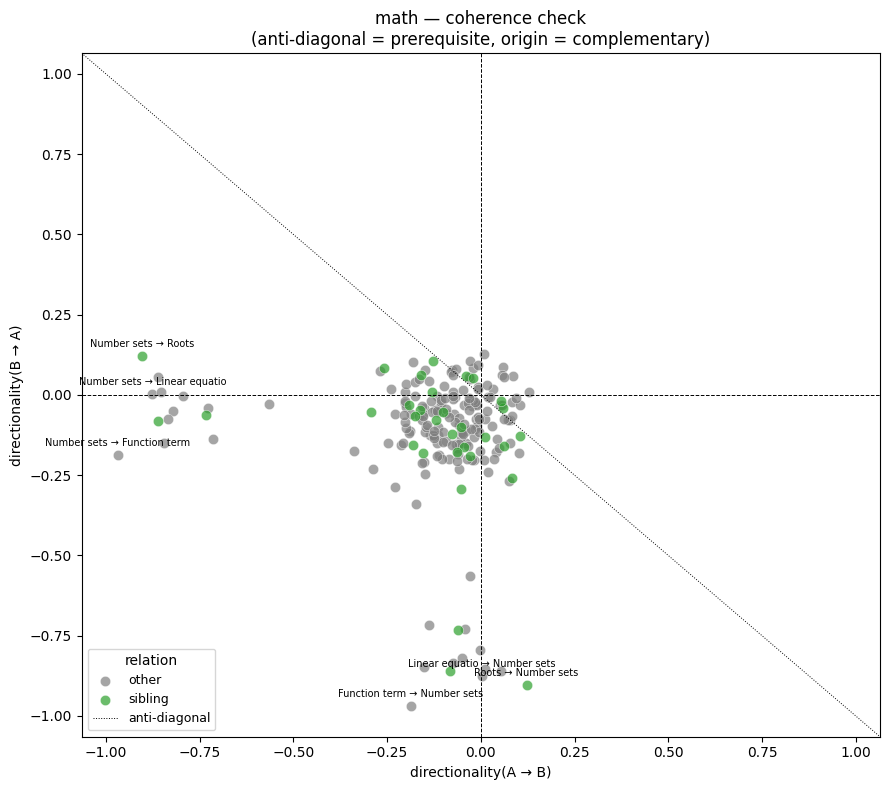

In [17]:
# Coherence scatter — math. Real prerequisite pairs sit near the anti-diagonal
# (top-left or bottom-right); complementary topics cluster at the origin.
df = outcome_with_reverse['math'].dropna(
    subset=['directionality', 'reverse_directionality']
)
fig, ax = plt.subplots(figsize=(9, 8))
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.7, s=55, edgecolors='white', linewidths=0.4)

lim = max(df['directionality'].abs().max(),
          df['reverse_directionality'].abs().max()) * 1.1
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(0, color='black', lw=0.7, ls='--')
ax.plot([-lim, lim], [lim, -lim], color='black', lw=0.7, ls=':', label='anti-diagonal')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

extremes = (df.assign(_r=lambda d: d['directionality']**2 +
                                    d['reverse_directionality']**2)
              .nlargest(6, '_r'))
for _, row in extremes.iterrows():
    ax.annotate(f"{row['source_name'][:14]} → {row['target_name'][:14]}",
                (row['directionality'], row['reverse_directionality']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_title('math — coherence check\n(anti-diagonal = prerequisite, origin = complementary)')
ax.legend(title='relation', fontsize=9, loc='lower left')
plt.tight_layout()
plt.savefig('rapport/coherence_math.png', dpi=150, bbox_inches='tight')
plt.show()

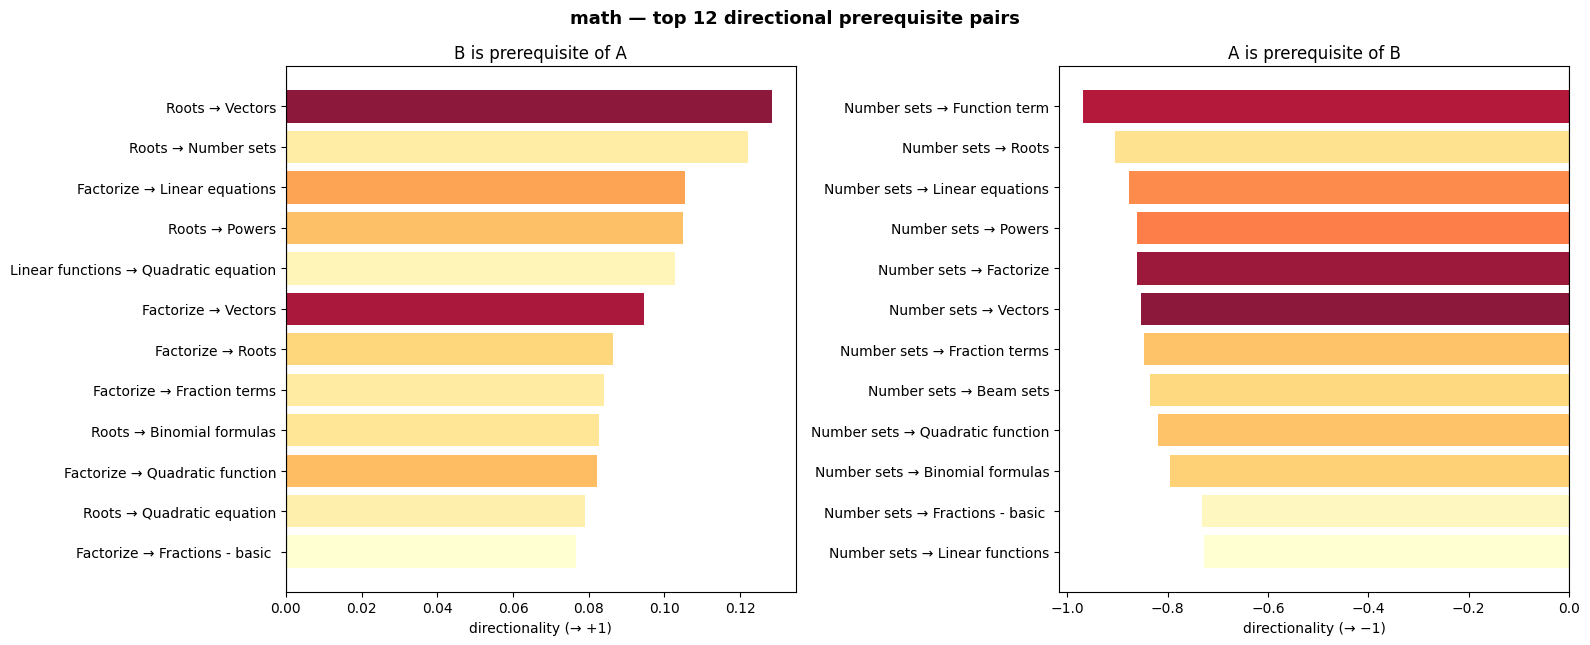

In [18]:
# Top prerequisite pairs — math. Bar color encodes relationship strength.
TOP_N = 12
df = outcome_with_reverse['math'].dropna(subset=['directionality', 'strength'])
high = df.nlargest(TOP_N,  'directionality').iloc[::-1]
low  = df.nsmallest(TOP_N, 'directionality').iloc[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 0.42 * TOP_N + 1.5))
cmap = plt.cm.YlOrRd

def _bars(ax, data, title, xlabel):
    norm = plt.Normalize(data['strength'].min(), data['strength'].max())
    labels = [f"{r['source_name'][:18]} → {r['target_name'][:18]}"
              for _, r in data.iterrows()]
    ax.barh(labels, data['directionality'],
            color=cmap(norm(data['strength'])), alpha=0.9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(xlabel); ax.set_title(title)

_bars(ax1, high, 'B is prerequisite of A', 'directionality (→ +1)')
_bars(ax2, low,  'A is prerequisite of B', 'directionality (→ −1)')
plt.suptitle(f'math — top {TOP_N} directional prerequisite pairs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rapport/prereq_bars_math.png', dpi=150, bbox_inches='tight')
plt.show()

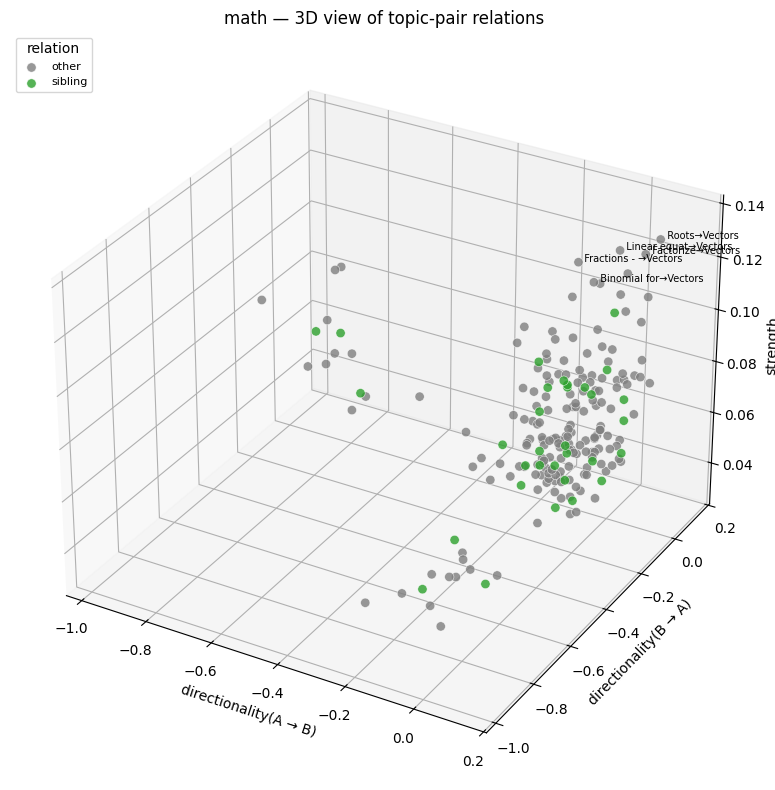

In [19]:
# 3D view — math: directionality(A→B), directionality(B→A), strength.
# Real prerequisite pairs lift along the diagonal of x and y opposite signs;
# complementary pairs sit near the (0, 0) line; strong pairs rise on z.
df = outcome_with_reverse['math'].dropna(
    subset=['directionality', 'reverse_directionality', 'strength']
)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'], grp['strength'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.8, s=45, edgecolors='white', linewidths=0.4)

# Annotate the 5 strongest pairs.
for _, row in df.nlargest(5, 'strength').iterrows():
    ax.text(row['directionality'], row['reverse_directionality'], row['strength'],
            f"  {row['source_name'][:12]}→{row['target_name'][:12]}",
            fontsize=7)

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_zlabel('strength')
ax.set_title('math — 3D view of topic-pair relations')
ax.legend(title='relation', fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

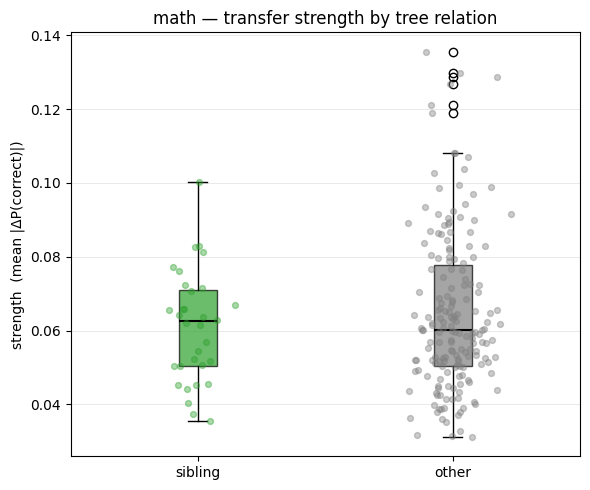

In [28]:
# Distribution of strength by relation type — math only.
fig, ax = plt.subplots(figsize=(6, 5))

df = outcome_with_reverse['math'].dropna(subset=['strength', 'relation'])
order = ['sibling', 'other']
colors = [RELATION_COLORS[r] for r in order]

data_by_rel = [df.loc[df['relation'] == r, 'strength'].values for r in order]
bp = ax.boxplot(data_by_rel, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)

for i, (rel, color) in enumerate(zip(order, colors), start=1):
    sub = df[df['relation'] == rel]['strength']
    ax.scatter(np.random.normal(i, 0.08, size=len(sub)), sub,
               color=color, alpha=0.4, s=18, zorder=3)

ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, fontsize=10)
ax.set_ylabel('strength  (mean |ΔP(correct)|)')
ax.set_title('math — transfer strength by tree relation')
ax.grid(axis='y', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('rapport/transfer_barplot.png', dpi=150, bbox_inches='tight')
plt.show()


## §4. German Analysis

In [20]:
# Top topic pairs by |directionality| — german.
german_top = (outcome_with_reverse['german']
              .assign(_abs=lambda d: d['directionality'].abs())
              .sort_values('_abs', ascending=False)
              .drop(columns='_abs')
              .head(20)
              .reset_index(drop=True))
german_top[['source_name', 'target_name', 'relation',
            'strength', 'directionality',
            'reverse_directionality', 'asymmetry',
            'n_obs_correct', 'n_obs_wrong']]

,source_name,target_name,relation,strength,directionality,reverse_directionality,asymmetry,n_obs_correct,n_obs_wrong
0,Spelling difficult words,Particles,other,0.089492,-1.148461,-0.086191,-1.062270,22637,1327
1,Comma for enumerations,Particles,other,0.136350,-0.883935,-0.078512,-0.805423,15960,2590
2,Spelling difficult words,Determination of the elements of the sentence,other,0.060368,-0.871474,0.017410,-0.888884,22637,1327
3,Spelling difficult words,Separation and combination,sibling,0.071320,-0.805488,-0.224981,-0.580507,22637,1327
4,Comma for enumerations,Determination of the elements of the sentence,other,0.098762,-0.725297,0.182119,-0.907416,15960,2590
5,Comma for enumerations,Pronoun,other,0.134453,-0.702784,-0.171488,-0.531296,15960,2590
6,Spelling difficult words,Pronoun,other,0.086577,-0.684807,-0.125759,-0.559049,22637,1327
7,Spelling difficult words,Noun,other,0.072411,-0.670644,0.068209,-0.738853,22637,1327
8,Spelling difficult words,Upper and lower case,sibling,0.094097,-0.644523,-0.352322,-0.292201,22637,1327
9,Comma for enumerations,Separation and combination,other,0.097073,-0.623384,-0.355449,-0.267935,15960,2590


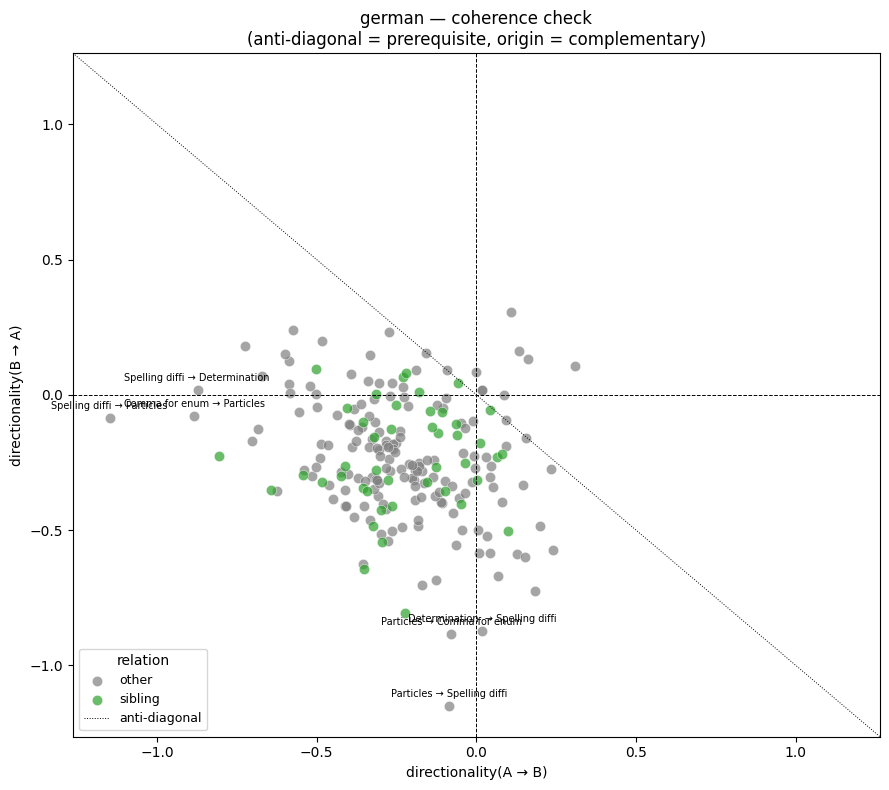

In [21]:
# Coherence scatter — german.
df = outcome_with_reverse['german'].dropna(
    subset=['directionality', 'reverse_directionality']
)
fig, ax = plt.subplots(figsize=(9, 8))
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.7, s=55, edgecolors='white', linewidths=0.4)

lim = max(df['directionality'].abs().max(),
          df['reverse_directionality'].abs().max()) * 1.1
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(0, color='black', lw=0.7, ls='--')
ax.plot([-lim, lim], [lim, -lim], color='black', lw=0.7, ls=':', label='anti-diagonal')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

extremes = (df.assign(_r=lambda d: d['directionality']**2 +
                                    d['reverse_directionality']**2)
              .nlargest(6, '_r'))
for _, row in extremes.iterrows():
    ax.annotate(f"{row['source_name'][:14]} → {row['target_name'][:14]}",
                (row['directionality'], row['reverse_directionality']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_title('german — coherence check\n(anti-diagonal = prerequisite, origin = complementary)')
ax.legend(title='relation', fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

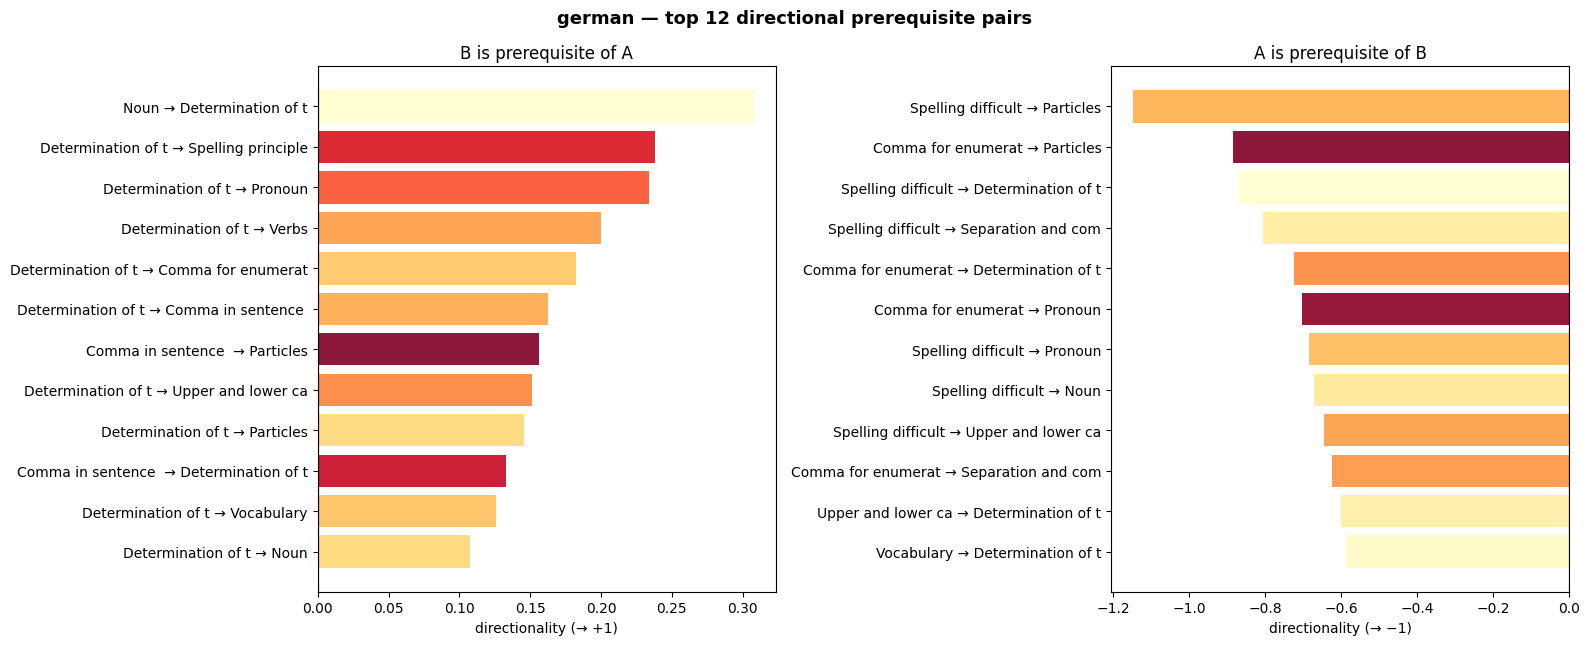

In [22]:
# Top prerequisite pairs — german. Bar color encodes relationship strength.
TOP_N = 12
df = outcome_with_reverse['german'].dropna(subset=['directionality', 'strength'])
high = df.nlargest(TOP_N,  'directionality').iloc[::-1]
low  = df.nsmallest(TOP_N, 'directionality').iloc[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 0.42 * TOP_N + 1.5))
cmap = plt.cm.YlOrRd

def _bars(ax, data, title, xlabel):
    norm = plt.Normalize(data['strength'].min(), data['strength'].max())
    labels = [f"{r['source_name'][:18]} → {r['target_name'][:18]}"
              for _, r in data.iterrows()]
    ax.barh(labels, data['directionality'],
            color=cmap(norm(data['strength'])), alpha=0.9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(xlabel); ax.set_title(title)

_bars(ax1, high, 'B is prerequisite of A', 'directionality (→ +1)')
_bars(ax2, low,  'A is prerequisite of B', 'directionality (→ −1)')
plt.suptitle(f'german — top {TOP_N} directional prerequisite pairs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

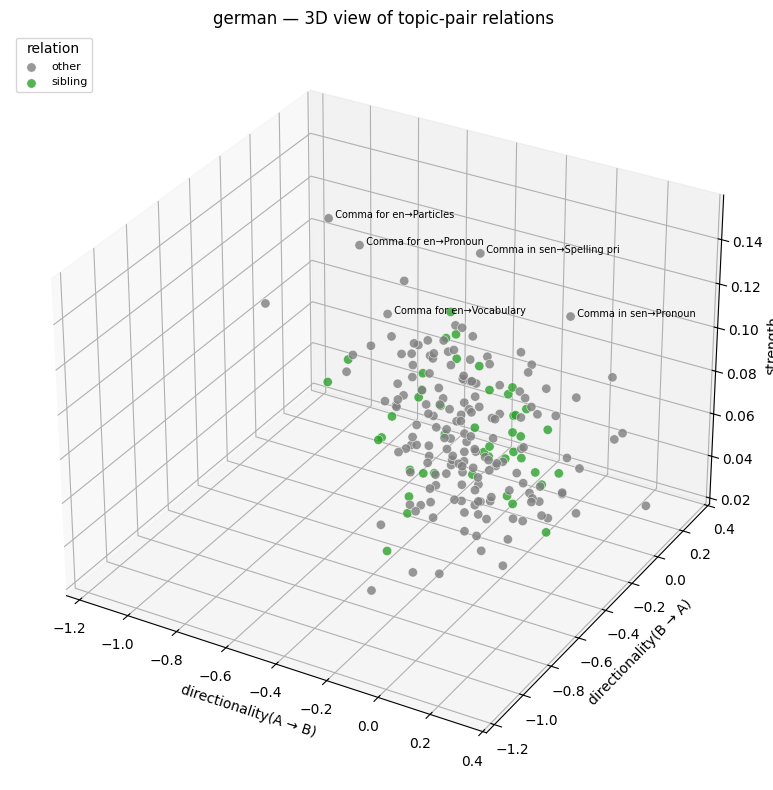

In [23]:
# 3D view — german: directionality(A→B), directionality(B→A), strength.
df = outcome_with_reverse['german'].dropna(
    subset=['directionality', 'reverse_directionality', 'strength']
)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'], grp['strength'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.8, s=45, edgecolors='white', linewidths=0.4)

for _, row in df.nlargest(5, 'strength').iterrows():
    ax.text(row['directionality'], row['reverse_directionality'], row['strength'],
            f"  {row['source_name'][:12]}→{row['target_name'][:12]}",
            fontsize=7)

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_zlabel('strength')
ax.set_title('german — 3D view of topic-pair relations')
ax.legend(title='relation', fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## §5. Cross-subject Comparison

,math,german
n_pairs,210.000,210.000
mean_strength,0.064,0.068
mean_|directionality|,0.142,0.265
%_strong_B_prereq_A,0.000,0.476
%_strong_A_prereq_B,7.143,38.571
%_complementary_(|d|<0.1),55.238,22.381


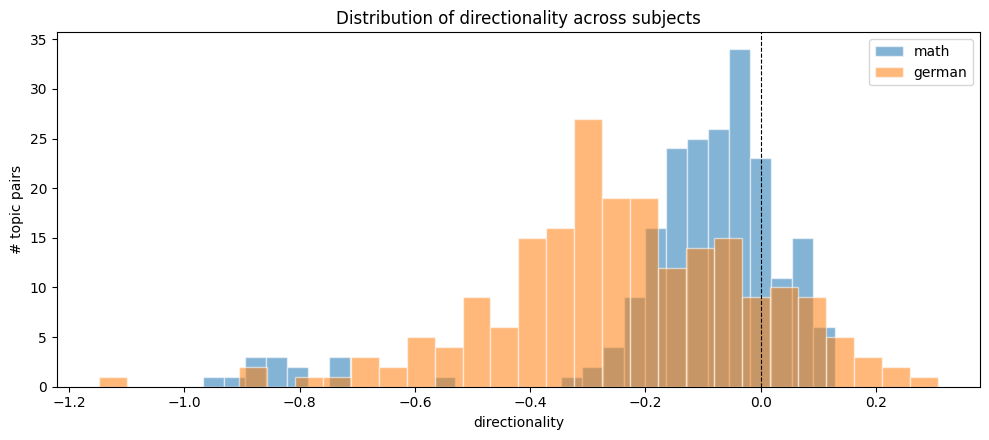

In [24]:
# Cross-subject summary: how directional are the topic-pair relations in each subject?
def _stats(df):
    df = df.dropna(subset=['directionality', 'strength'])
    return pd.Series({
        'n_pairs':                  len(df),
        'mean_strength':            df['strength'].mean(),
        'mean_|directionality|':    df['directionality'].abs().mean(),
        '%_strong_B_prereq_A':      (df['directionality'] >  0.3).mean() * 100,
        '%_strong_A_prereq_B':      (df['directionality'] < -0.3).mean() * 100,
        '%_complementary_(|d|<0.1)': (df['directionality'].abs() < 0.1).mean() * 100,
    })

summary = pd.DataFrame({s: _stats(outcome_with_reverse[s]) for s in SUBJECTS}).round(3)
display(summary)

# Side-by-side directionality distribution.
fig, ax = plt.subplots(figsize=(10, 4.5))
for subject, color in zip(SUBJECTS, ['tab:blue', 'tab:orange']):
    df = outcome_with_reverse[subject].dropna(subset=['directionality'])
    ax.hist(df['directionality'], bins=30, alpha=0.55, label=subject,
            color=color, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('directionality'); ax.set_ylabel('# topic pairs')
ax.set_title('Distribution of directionality across subjects')
ax.legend()
plt.tight_layout()
plt.show()

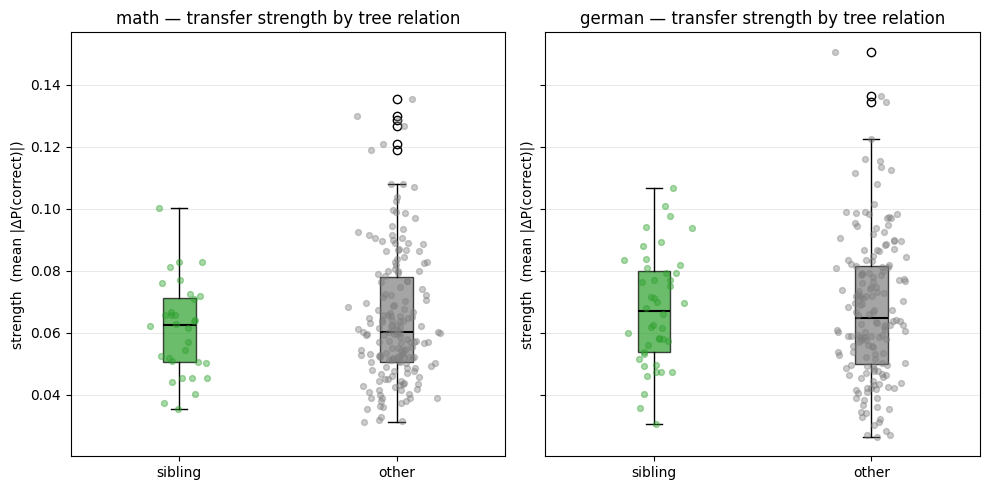

In [29]:
# Distribution of strength by relation type — both subjects side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, subject in zip(axes, SUBJECTS):
    df = outcome_with_reverse[subject].dropna(subset=['strength', 'relation'])
    order = ['sibling', 'other']
    colors = [RELATION_COLORS[r] for r in order]

    data_by_rel = [df.loc[df['relation'] == r, 'strength'].values for r in order]
    bp = ax.boxplot(data_by_rel, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=1.5))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    for i, (rel, color) in enumerate(zip(order, colors), start=1):
        sub = df[df['relation'] == rel]['strength']
        ax.scatter(np.random.normal(i, 0.08, size=len(sub)), sub,
                   color=color, alpha=0.4, s=18, zorder=3)

    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(order, fontsize=10)
    ax.set_ylabel('strength  (mean |ΔP(correct)|)')
    ax.set_title(f'{subject} — transfer strength by tree relation')
    ax.grid(axis='y', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('rapport/transfer_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

- **The reverse-coherence check is a real falsifiability test.** A true prerequisite relation has to be asymmetric — answering A correctly should reveal B's mastery in a way that answering B correctly does not reveal A's. The `directionality(A→B)` vs `directionality(B→A)` scatter operationalizes this directly: pairs near the anti-diagonal pass the check; pairs near the origin behave symmetrically and are better described as **co-occurring / complementary** topics rather than prerequisites. This means the method comes with a built-in way to reject false positives, not just rank candidates.

- **The 3D view (directionality A→B, directionality B→A, strength) is where the analysis pays off.** Two-dimensional projections can hide that a strongly directional pair has near-zero `strength` — meaning the model barely moves either way. Reading the 3D scatter, the credible prerequisite candidates are pairs with simultaneously high `strength` and high |asymmetry|; everything at low z is decoration regardless of where it sits on the directionality plane.

- **Math and German give the method different shapes of evidence.** Math has many small, well-attempted leaf topics that share basic operations as ancestors — a structure where directional prerequisite signals are exactly what you'd expect to recover. German is flatter and more lexical: a much larger share of pairs falls in the symmetric / complementary region, which is consistent with a domain where many topics are parallel facets of language rather than ordered building blocks. Reading both subjects' coherence plots side by side is the clearest way to see this difference.